Predict threatened status using IUCN+WWF data (taxonomy = habitat proxy).
Data Lifecycle: Load → Clean → Features → Ensemble Model → Top Risks.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
# Load datasets
df_wwf = pd.read_csv('/Users/hinahaq/Downloads/ML Project/clean_data/cleaned_wildlife.csv')
df_iucn = pd.read_csv('/Users/hinahaq/Downloads/ML Project/clean_data/cleaned_iucn.csv')

# WWF prep
df_wwf['scientific_name'] = df_wwf['Scientific Name'].fillna('') + ' ' + df_wwf['Common Name'].fillna('')
df_wwf['threatened'] = df_wwf['Conservation Status'].isin(['Critically Endangered', 'Endangered', 'Vulnerable']).astype(int)

print('WWF:', df_wwf.shape, 'Threatened:', df_wwf.threatened.mean())
print(df_wwf[['scientific_name', 'threatened']].head())

WWF: (82, 6) Threatened: 0.7560975609756098
                                     scientific_name  threatened
0                            African Forest Elephant           1
1  Loxodonta africana africana African Savanna El...           1
2                     Lycaon pictus African Wild Dog           1
3                     Thunnus alalunga Albacore Tuna           0
4            Panthera pardus orientalis Amur Leopard           1


IUCN base + WWF icons. Taxonomy (kingdom/family) as habitat proxies.
Encode categoricals for model.

In [26]:
# IUCN base (big data)
df_final = df_iucn.copy()

# Add WWF threatened matches
for idx, row in df_wwf.iterrows():
    mask = df_final['scientific_name'].str.contains(row['scientific_name'], case=False, na=False)
    df_final.loc[mask, 'threatened'] = row['threatened']

# Habitat proxy
df_final['ispolar'] = df_final['main_common_name'].fillna('').str.contains('Polar|Arctic|Beluga', case=False).astype(int)

print('Merged:', df_final.shape, 'Threatened:', df_final.threatened.mean())
print(df_final.head())

Merged: (159542, 19) Threatened: 0.2736520790763561
   taxonid kingdom_name   phylum_name     class_name order_name  \
0    31665      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
1    31666      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
2    31668      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
3    31669      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
4    31670      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   

       family_name  genus_name      scientific_name taxonomic_authority  \
0        MYRTACEAE      Myrcia  Myrcia manacalensis                Urb.   
1        MYRTACEAE     Psidium    Psidium claraense                Urb.   
2        MYRTACEAE     Mosiera   Mosiera havanensis        (Urb.) Bisse   
3  MELASTOMATACEAE  Henriettea  Henriettea punctata   (Griseb.) M.Gómez   
4  MELASTOMATACEAE  Henriettea  Henriettea squamata       (Alain) Alain   

  infra_rank infra_name population category main_common_name  threatened  \
0        NaN      

In [27]:
# Encode taxonomy (kingdom/family = habitat clues). Split train/test.
from sklearn.preprocessing import LabelEncoder

# Encode features
le = LabelEncoder()
features = ['kingdom_name', 'phylum_name', 'class_name', 'family_name', 'marine', 'carnivore', 'large_mammal']
for f in features:
    df_final[f + '_enc'] = le.fit_transform(df_final[f].astype(str).fillna('missing'))

feature_cols = [f+'_enc' for f in features] + ['ispolar']
X = df_final[feature_cols].fillna(0)
y = df_final['threatened']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Features:', feature_cols)
print('Train threatened:', y_train.mean())


Features: ['kingdom_name_enc', 'phylum_name_enc', 'class_name_enc', 'family_name_enc', 'marine_enc', 'carnivore_enc', 'large_mammal_enc', 'ispolar']
Train threatened: 0.27365179851605775


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Train (balanced weights)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=10)
model.fit(X_train, y_train)

# Scores
print('Train acc:', model.score(X_train, y_train))
print('Test acc:', model.score(X_test, y_test))

# Importances
print('\nFeature Importances:')
for i, col in enumerate(feature_cols):
    print(f'{col}: {model.feature_importances_[i]:.3f}')

Train acc: 0.623357595606152
Test acc: 0.6209533360493904

Feature Importances:
kingdom_name_enc: 0.186
phylum_name_enc: 0.261
class_name_enc: 0.270
family_name_enc: 0.281
marine_enc: 0.000
carnivore_enc: 0.000
large_mammal_enc: 0.000
ispolar: 0.001


In [29]:
#tuning
from sklearn.model_selection import GridSearchCV

# Grid search (fast CV)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                    param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)

# Use best model
model = grid.best_estimator_
print("New test acc:", model.score(X_test, y_test))


Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best F1: 0.5413927411868845
New test acc: 0.6398821649064528


In [30]:
# Engineering on train/test (add interaction)
top_features = ['kingdom_name_enc', 'phylum_name_enc', 'class_name_enc', 'family_name_enc', 'ispolar']
X_train_eng = X_train[top_features].copy()
X_test_eng = X_test[top_features].copy()

# Add interaction feature
X_train_eng['taxo_risk'] = X_train_eng['kingdom_name_enc'] * X_train_eng['family_name_enc']
X_test_eng['taxo_risk'] = X_test_eng['kingdom_name_enc'] * X_test_eng['family_name_enc']

# Retrain
model_eng = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', random_state=42)
model_eng.fit(X_train_eng, y_train)
print("Engineered test acc:", model_eng.score(X_test_eng, y_test))
print("Importances:", model_eng.feature_importances_)

Engineered test acc: 0.6405089473189383
Importances: [0.10967694 0.08230828 0.16466283 0.4573033  0.00049171 0.18555693]


In [31]:
from sklearn.model_selection import GridSearchCV

# Expanded grid (lesson-style)
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [25, 30],
    'min_samples_split': [2, 10],
    'max_features': ['sqrt', 'log2']
}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1), 
                    param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_eng, y_train)

print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)
print("Test acc:", grid.score(X_test_eng, y_test))

model = grid.best_estimator_  

Best params: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best F1: 0.5419652304768503
Test acc: 0.5439183803602742


Tree: 74.4%
Bagging: 74.5%
RandomForest: 64.1%
AdaBoost: 74.4%
GradientBoost: 74.4%


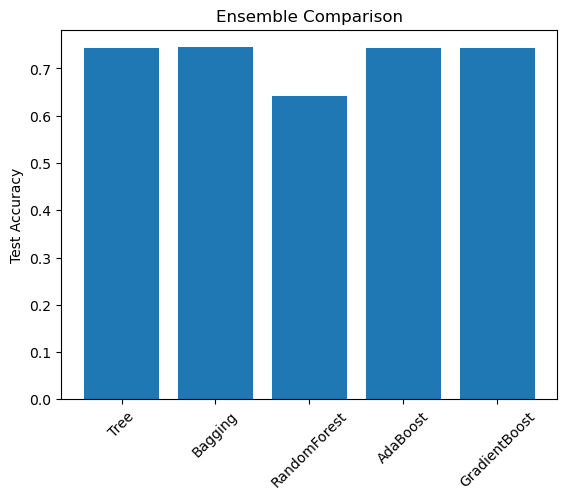

In [32]:
#Compare: DecisionTree → Bagging → RandomForest → AdaBoost/GradientBoost.

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

models = {
    'Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Bagging': BaggingClassifier(DecisionTreeClassifier(max_depth=20), n_estimators=100, random_state=42),
    'RandomForest': model,  
    'AdaBoost': AdaBoostClassifier(DecisionTreeClassifier(max_depth=20), n_estimators=100, random_state=42),
    'GradientBoost': GradientBoostingClassifier(max_depth=20, n_estimators=100, random_state=42)
}

results = {}
for name, mod in models.items():
    mod.fit(X_train_eng, y_train)
    results[name] = mod.score(X_test_eng, y_test)
    print(f"{name}: {results[name]:.1%}")

plt.bar(results.keys(), results.values())
plt.ylabel('Test Accuracy')
plt.title('Ensemble Comparison')
plt.xticks(rotation=45)
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score

# CV on Bagging winner 
bagging = BaggingClassifier(DecisionTreeClassifier(max_depth=20), n_estimators=100, random_state=42)
cv_scores = cross_val_score(bagging, X_train_eng, y_train, cv=5, scoring='accuracy')

print("Bagging CV acc:", cv_scores.mean(), "+/-", cv_scores.std())
print("CV scores:", cv_scores)

# Retrain best on full train
bagging.fit(X_train_eng, y_train)
print("Final test:", bagging.score(X_test_eng, y_test))

Bagging CV acc: 0.7420102929609191 +/- 0.0012062942649730558
CV scores: [0.74176362 0.74317389 0.74137188 0.74022565 0.74351641]
Final test: 0.7446175060327808


In [34]:
# Engineering on train/test (add interaction)
top_features = ['kingdom_name_enc', 'phylum_name_enc', 'class_name_enc', 'family_name_enc', 'ispolar']
X_train_eng = X_train[top_features].copy()
X_test_eng = X_test[top_features].copy()

# Add interaction feature
X_train_eng['taxo_risk'] = X_train_eng['kingdom_name_enc'] * X_train_eng['family_name_enc']
X_test_eng['taxo_risk'] = X_test_eng['kingdom_name_enc'] * X_test_eng['family_name_enc']

In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

bagging = BaggingClassifier(
    DecisionTreeClassifier(max_depth=20),
    n_estimators=100,
    random_state=42
)

cv_scores = cross_val_score(bagging, X_train_eng, y_train, cv=5, scoring='accuracy')
print("Bagging CV acc:", cv_scores.mean(), "+/-", cv_scores.std())
print("CV scores:", cv_scores)

bagging.fit(X_train_eng, y_train)
y_pred = bagging.predict(X_test_eng)

print("Final test acc:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Bagging CV acc: 0.7420102929609191 +/- 0.0012062942649730558
CV scores: [0.74176362 0.74317389 0.74137188 0.74022565 0.74351641]
Final test acc: 0.7446175060327808

Confusion matrix:
[[22046  1131]
 [ 7018  1714]]

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.84     23177
           1       0.60      0.20      0.30      8732

    accuracy                           0.74     31909
   macro avg       0.68      0.57      0.57     31909
weighted avg       0.72      0.74      0.69     31909



In [36]:
from sklearn.metrics import classification_report, confusion_matrix

# Get probability of class 1 = threatened
y_proba = bagging.predict_proba(X_test_eng)[:, 1]

# Try a lower threshold than 0.50
threshold = 0.35
y_pred_thr = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thr))
print("\nClassification report:\n", classification_report(y_test, y_pred_thr))

Threshold: 0.35
Confusion matrix:
 [[16619  6558]
 [ 3270  5462]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.72      0.77     23177
           1       0.45      0.63      0.53      8732

    accuracy                           0.69     31909
   macro avg       0.64      0.67      0.65     31909
weighted avg       0.73      0.69      0.70     31909




RISK DRIVERS (Bagging Avg):
kingdom_name_enc: 17.7%
phylum_name_enc: 1.6%
class_name_enc: 12.7%
family_name_enc: 44.4%
ispolar: 0.1%
taxo_risk: 23.6%


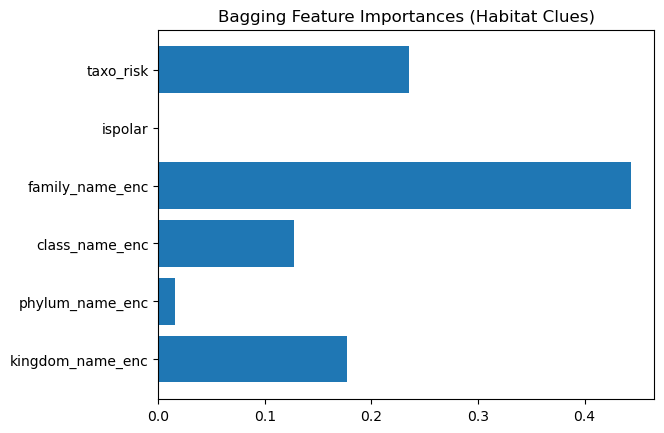

In [37]:
# Bagging importances (average trees)
print("\nRISK DRIVERS (Bagging Avg):")
tree_importances = np.mean([tree.feature_importances_ for tree in bagging.estimators_], axis=0)
for i, col in enumerate(X_train_eng.columns):
    imp = tree_importances[i]
    print(f"{col}: {imp:.1%}")

# Viz
plt.barh(X_train_eng.columns, tree_importances)
plt.title('Bagging Feature Importances (Habitat Clues)')
plt.show()

In [38]:
# Show the top 5 species most likely to be threatened

test_results = X_test_eng.copy()
test_results["scientific_name"] = df_final.loc[X_test_eng.index, "scientific_name"]
test_results["actual_threatened"] = y_test.values

# probability of threatened class
test_results["pred_threat_prob"] = bagging.predict_proba(X_test_eng)[:, 1]

# rank from highest risk to lowest risk
top5_threatened = test_results.sort_values("pred_threat_prob", ascending=False).head(5)

print("Top 5 predicted threatened species:")
print(top5_threatened[["scientific_name", "actual_threatened", "pred_threat_prob"]])

Top 5 predicted threatened species:
                scientific_name  actual_threatened  pred_threat_prob
144146       Acipenser ruthenus                  1               1.0
7699       Cookeconcha contorta                  1               1.0
153690     Acipenser oxyrinchus                  1               1.0
97834   Acipenser transmontanus                  1               1.0
83557           Meta stridulans                  0               1.0


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

test_results = X_test_eng.copy()
test_results["scientific_name"] = df_final.loc[X_test_eng.index, "scientific_name"]
test_results["actual_threatened"] = y_test.values
test_results["pred_threatened"] = bagging.predict(X_test_eng)

print(confusion_matrix(test_results["actual_threatened"], test_results["pred_threatened"]))
print(classification_report(test_results["actual_threatened"], test_results["pred_threatened"]))

[[22046  1131]
 [ 7018  1714]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.84     23177
           1       0.60      0.20      0.30      8732

    accuracy                           0.74     31909
   macro avg       0.68      0.57      0.57     31909
weighted avg       0.72      0.74      0.69     31909



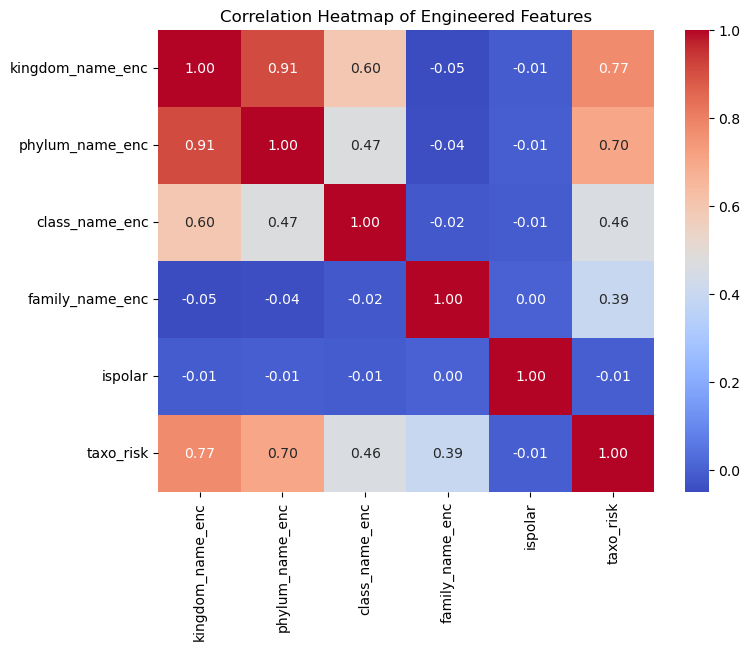

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select engineered numeric columns
corr_cols = [
    "kingdom_name_enc",
    "phylum_name_enc",
    "class_name_enc",
    "family_name_enc",
    "ispolar",
    "taxo_risk"
]

# Compute correlation matrix
corr_matrix = X_train_eng[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

### Correlation Heatmap

This heatmap shows how the engineered numeric features relate to each other. It helps us check whether some variables move together and whether the interaction feature `taxo_risk` is strongly linked to the taxonomy variables used to build it.

**Important:** Most of these variables are label-encoded categories, so the heatmap is exploratory. The correlations should not be interpreted as strong scientific relationships.